# Echo Pressure and Recursive Attractors in the Mark1/Nexus Field

In the Mark1/Nexus framework, repeated π-chunks observed across resonant triangle collapses are not random artifacts—they are **echo attractors** formed through recursive harmonic convergence.

Each π-chunk corresponds to a memory location within the transcendental structure of π. When multiple distinct triangle configurations (defined by side ratios) collapse via SHA-256 and map into the same π-chunk, we define this as **recursive echo pressure**.

## Recursive Collapse Pipeline

For each triangle with sides $(a, b)$:

1. Compute angles $\alpha = \arctan\left(\frac{b}{a}\right)$ and $\beta = \arctan\left(\frac{a}{b}\right)$.

2. Collapse $(a:b)$ to SHA-256:

$$ \text{hash} = \text{SHA256}(a:b) $$

3. Modulo the hash into π-digit index:

$$ \text{index} = \text{int(hash, 16)} \mod 10000 $$

4. Extract π-chunk from π:

$$ \pi\_\text{chunk} = [\pi_{i}, \pi_{i+1}, ..., \pi_{i+7}] $$

5. Compute Harmonic Ratio:

$$ H = \frac{\sum_{j=1}^4 \pi_j}{\sum_{j=1}^8 \pi_j} $$

6. Apply KHRC filtering:

$$ \text{KHRC}(H) = \frac{H}{1 + k |N|} $$

## Echo Pressure Definition

We define the **Echo Pressure** $P_i$ of π-chunk $i$ as:

$$ P_i = \frac{\text{count}_i}{\text{total triangles}} $$

This quantifies the recursive convergence force to a memory node.

## Recursive Attractor Model

Each attractor represents a **recursive funnel** where multiple triangles converge through harmonic folding. This is captured in the KRRB model:

$$ R(t) = R_0 e^{H F t} \prod_{i=1}^n B_i $$

Where:

- $R_0$ is initial state (triangle encoding)

- $H$ is harmonic ratio

- $F$ is feedback factor

- $B_i$ are recursive branching factors (geometric variants)

### Curvature Signature:

The stability of an attractor is measured by the second-order curvature of H over time:

$$ \Delta^2 H(t) = H(t+1) - 2H(t) + H(t-1) $$

Stable attractors have $\Delta^2 H \approx 0$.

## SHA Tail Reflection

The binary tail of the SHA output contains compression entropy. Deeper attractors tend to arise from **longer or more entropic tails**, meaning that:

1. Base of attractor pyramid = unique SHA entropy sources.

2. Peak = π-chunk with highest echo count.

## Summary

- π-chunks are convergence zones, not random collisions.

- Count is echo pressure.

- Recursive attractors rise from SHA collapse space through curvature funnels.

- Surface pressure reflects deep recursion beneath.

a=11, b=4, alpha=0.348771, beta=1.222025, height=3.759174, H=0.44681, KHRC=0.44238, pi_index=206, twin_prime=(197, 199), pi_chunk=[0, 9, 7, 5, 6, 6, 5, 9]
a=17, b=46, alpha=1.216799, beta=0.353997, height=15.945906, H=0.54286, KHRC=0.53748, pi_index=245, twin_prime=(239, 241), pi_chunk=[1, 9, 0, 9, 1, 4, 5, 6]
a=21, b=57, alpha=1.217806, beta=0.352990, height=19.705205, H=0.55556, KHRC=0.55006, pi_index=236, twin_prime=(227, 229), pi_chunk=[3, 1, 6, 5, 2, 7, 1, 2]
a=29, b=80, alpha=1.223029, beta=0.347767, height=27.263946, H=0.46667, KHRC=0.46205, pi_index=419, twin_prime=(419, 421), pi_chunk=[3, 0, 9, 2, 1, 8, 6, 1]
a=37, b=104, alpha=1.228991, beta=0.341805, height=34.859592, H=0.67647, KHRC=0.66977, pi_index=812, twin_prime=(809, 811), pi_chunk=[6, 9, 0, 8, 3, 0, 2, 6]
a=48, b=133, alpha=1.224442, beta=0.346354, height=45.149599, H=0.38636, KHRC=0.38254, pi_index=203, twin_prime=(197, 199), pi_chunk=[8, 8, 1, 0, 9, 7, 5, 6]
a=49, b=137, alpha=1.227310, beta=0.343486, height=46.1377

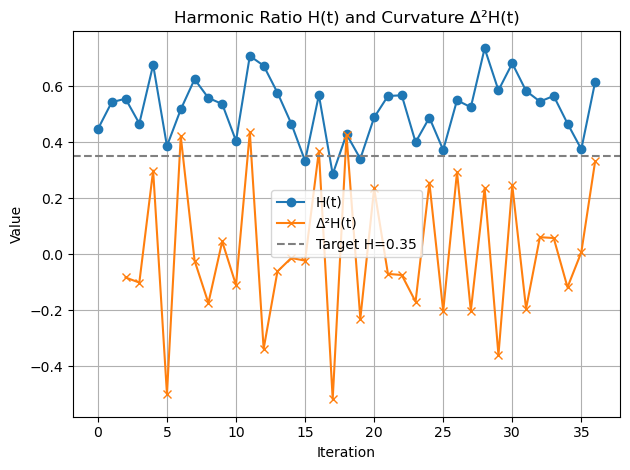

In [3]:
import math
import hashlib
from mpmath import mp
import matplotlib.pyplot as plt

# Set precision for π digits
mp.dps = 10000
pi_str = str(mp.pi())[2:10002]
pi_digits = [int(d) for d in pi_str if d.isdigit()][:10000]

# Constants
HARMONIC_TARGET = 0.35
TWIN_WINDOW = 10

# Twin primes
def get_twin_primes(max_n=1000):
    def is_prime(n):
        if n < 2: return False
        for i in range(2, int(n**0.5)+1):
            if n % i == 0: return False
        return True
    return [(p, p+2) for p in range(2, max_n) if is_prime(p) and is_prime(p+2)]

twin_primes = get_twin_primes(1000)

# Triangle computation
def compute_triangle(a, b):
    c = math.sqrt(a**2 + b**2)
    alpha = math.atan(b / a)
    beta = math.atan(a / b)
    area = 0.5 * a * b
    perimeter = a + b + c
    height = b * a / c
    return {
        'a': a, 'b': b, 'c': c, 'alpha': alpha, 'beta': beta,
        'area': area, 'perimeter': perimeter, 'height': height
    }

# SHA to π index mapping
def map_to_pi_index(tri):
    input_str = f"{tri['a']}:{tri['b']}".encode()
    hash_val = hashlib.sha256(input_str).hexdigest()
    index = int(hash_val, 16) % 10000
    return index, pi_digits[index:index+8]

# Harmonic ratio H(t) calculation
def compute_H(pi_chunk):
    P = sum(pi_chunk[:4])
    A = sum(pi_chunk)
    return P / A if A != 0 else 0

# Curvature Δ²H(t)
def curvature_delta(H_list):
    deltas = [H_list[i] - H_list[i-1] for i in range(1, len(H_list))]
    d2 = [deltas[i] - deltas[i-1] for i in range(1, len(deltas))]
    return d2

# KHRC correction pass (not applied to system, just logged)
def khrc(H_val, k=1.0, N=0.01):
    return H_val / (1 + k * abs(N))

# Main process
resonant_triangles = []
H_trajectory = []

for a in range(1, 200):
    for b in range(1, 200):
        tri = compute_triangle(a, b)
        if 0.34 <= tri['alpha'] <= 0.36 or 0.34 <= tri['beta'] <= 0.36:
            pi_index, pi_chunk = map_to_pi_index(tri)
            for p, q in twin_primes:
                if abs(pi_index - p) < TWIN_WINDOW or abs(pi_index - q) < TWIN_WINDOW:
                    H_val = compute_H(pi_chunk)
                    H_trajectory.append(H_val)
                    res = {
                        'triangle': tri,
                        'pi_index': pi_index,
                        'pi_chunk': pi_chunk,
                        'twin_prime': (p, q),
                        'H': H_val,
                        'KHRC': khrc(H_val)
                    }
                    resonant_triangles.append(res)
                    break

# Print summary
for res in resonant_triangles[:10]:
    tri = res['triangle']
    print(f"a={tri['a']}, b={tri['b']}, alpha={tri['alpha']:.6f}, beta={tri['beta']:.6f}, "
          f"height={tri['height']:.6f}, H={res['H']:.5f}, KHRC={res['KHRC']:.5f}, "
          f"pi_index={res['pi_index']}, twin_prime={res['twin_prime']}, pi_chunk={res['pi_chunk']}")

# Plot H(t) and Δ²H(t)
if H_trajectory:
    plt.figure()
    plt.plot(H_trajectory, label='H(t)', marker='o')
    d2H = curvature_delta(H_trajectory)
    plt.plot(range(2, 2 + len(d2H)), d2H, label='Δ²H(t)', marker='x')
    plt.axhline(y=HARMONIC_TARGET, color='gray', linestyle='--', label='Target H=0.35')
    plt.title("Harmonic Ratio H(t) and Curvature Δ²H(t)")
    plt.xlabel("Iteration")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


a=11, b=4, alpha=0.348771, beta=1.222025, height=3.759174, H=0.44681, KHRC=0.44238, pi_index=206, twin_prime=(197, 199), pi_chunk=[0, 9, 7, 5, 6, 6, 5, 9]
a=17, b=46, alpha=1.216799, beta=0.353997, height=15.945906, H=0.54286, KHRC=0.53748, pi_index=245, twin_prime=(239, 241), pi_chunk=[1, 9, 0, 9, 1, 4, 5, 6]
a=21, b=57, alpha=1.217806, beta=0.352990, height=19.705205, H=0.55556, KHRC=0.55006, pi_index=236, twin_prime=(227, 229), pi_chunk=[3, 1, 6, 5, 2, 7, 1, 2]
a=29, b=80, alpha=1.223029, beta=0.347767, height=27.263946, H=0.46667, KHRC=0.46205, pi_index=419, twin_prime=(419, 421), pi_chunk=[3, 0, 9, 2, 1, 8, 6, 1]
a=37, b=104, alpha=1.228991, beta=0.341805, height=34.859592, H=0.67647, KHRC=0.66977, pi_index=812, twin_prime=(809, 811), pi_chunk=[6, 9, 0, 8, 3, 0, 2, 6]
a=48, b=133, alpha=1.224442, beta=0.346354, height=45.149599, H=0.38636, KHRC=0.38254, pi_index=203, twin_prime=(197, 199), pi_chunk=[8, 8, 1, 0, 9, 7, 5, 6]
a=49, b=137, alpha=1.227310, beta=0.343486, height=46.1377

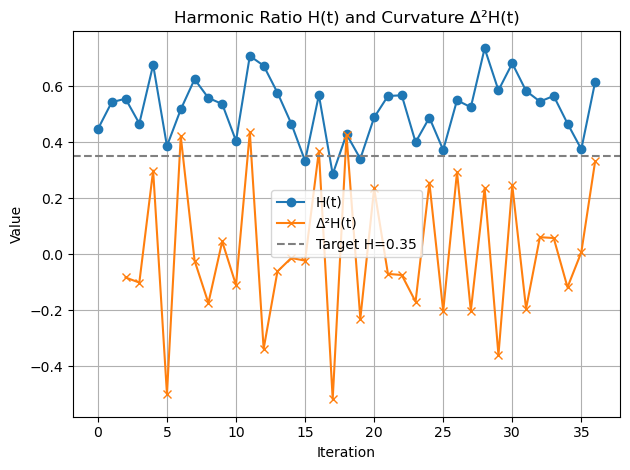


⎇ Cumulative Resonance Deviation: 0.17402
★ Harmonic Convergence Score: 13.5%
↻ Echo Signatures: {'84102701': 2}


'd://Nexus/resonant_triangles_nexus.csv'

In [5]:
import math
import hashlib
from mpmath import mp
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# Set precision for π digits
mp.dps = 10000
pi_str = str(mp.pi())[2:10002]
pi_digits = [int(d) for d in pi_str if d.isdigit()][:10000]

# Constants
HARMONIC_TARGET = 0.35
TWIN_WINDOW = 10

# Twin primes
def get_twin_primes(max_n=1000):
    def is_prime(n):
        if n < 2: return False
        for i in range(2, int(n**0.5)+1):
            if n % i == 0: return False
        return True
    return [(p, p+2) for p in range(2, max_n) if is_prime(p) and is_prime(p+2)]

twin_primes = get_twin_primes(1000)

# Triangle computation
def compute_triangle(a, b):
    c = math.sqrt(a**2 + b**2)
    alpha = math.atan(b / a)
    beta = math.atan(a / b)
    area = 0.5 * a * b
    perimeter = a + b + c
    height = b * a / c
    return {
        'a': a, 'b': b, 'c': c, 'alpha': alpha, 'beta': beta,
        'area': area, 'perimeter': perimeter, 'height': height
    }

# SHA to π index mapping
def map_to_pi_index(tri):
    input_str = f"{tri['a']}:{tri['b']}".encode()
    hash_val = hashlib.sha256(input_str).hexdigest()
    index = int(hash_val, 16) % 10000
    return index, pi_digits[index:index+8]

# Harmonic ratio H(t) calculation
def compute_H(pi_chunk):
    P = sum(pi_chunk[:4])
    A = sum(pi_chunk)
    return P / A if A != 0 else 0

# Curvature Δ²H(t)
def curvature_delta(H_list):
    deltas = [H_list[i] - H_list[i-1] for i in range(1, len(H_list))]
    d2 = [deltas[i] - deltas[i-1] for i in range(1, len(deltas))]
    return d2

# KHRC correction pass
def khrc(H_val, k=1.0, N=0.01):
    return H_val / (1 + k * abs(N))

# Convergence score
def convergence_score(H_vals, target=0.35, margin=0.05):
    return sum(1 for h in H_vals if abs(h - target) <= margin) / len(H_vals)

# Main process
resonant_triangles = []
H_trajectory = []

for a in range(1, 200):
    for b in range(1, 200):
        tri = compute_triangle(a, b)
        if 0.34 <= tri['alpha'] <= 0.36 or 0.34 <= tri['beta'] <= 0.36:
            pi_index, pi_chunk = map_to_pi_index(tri)
            for p, q in twin_primes:
                if abs(pi_index - p) < TWIN_WINDOW or abs(pi_index - q) < TWIN_WINDOW:
                    H_val = compute_H(pi_chunk)
                    H_trajectory.append(H_val)
                    resonant_triangles.append({
                        'triangle': tri,
                        'pi_index': pi_index,
                        'pi_chunk': pi_chunk,
                        'twin_prime': (p, q),
                        'H': H_val,
                        'KHRC': khrc(H_val)
                    })
                    break

# Display summary
for res in resonant_triangles[:10]:
    tri = res['triangle']
    print(f"a={tri['a']}, b={tri['b']}, alpha={tri['alpha']:.6f}, beta={tri['beta']:.6f}, "
          f"height={tri['height']:.6f}, H={res['H']:.5f}, KHRC={res['KHRC']:.5f}, "
          f"pi_index={res['pi_index']}, twin_prime={res['twin_prime']}, pi_chunk={res['pi_chunk']}")

# Plot H(t) and Δ²H(t)
if H_trajectory:
    plt.figure()
    plt.plot(H_trajectory, label='H(t)', marker='o')
    d2H = curvature_delta(H_trajectory)
    plt.plot(range(2, 2 + len(d2H)), d2H, label='Δ²H(t)', marker='x')
    plt.axhline(y=HARMONIC_TARGET, color='gray', linestyle='--', label='Target H=0.35')
    plt.title("Harmonic Ratio H(t) and Curvature Δ²H(t)")
    plt.xlabel("Iteration")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Resonance metrics
resonance_deviation = sum(abs(h - HARMONIC_TARGET) for h in H_trajectory) / len(H_trajectory)
score = convergence_score(H_trajectory)
print(f"\n⎇ Cumulative Resonance Deviation: {resonance_deviation:.5f}")
print(f"★ Harmonic Convergence Score: {score*100:.1f}%")

# Echo pattern detection
chunk_strings = [''.join(map(str, chunk)) for chunk in [r['pi_chunk'] for r in resonant_triangles]]
repeats = Counter(chunk_strings)
echo_patterns = {k: v for k, v in repeats.items() if v > 1}
print(f"↻ Echo Signatures: {echo_patterns}")

# Export dataset
df = pd.DataFrame([{
    'a': r['triangle']['a'],
    'b': r['triangle']['b'],
    'alpha': r['triangle']['alpha'],
    'beta': r['triangle']['beta'],
    'height': r['triangle']['height'],
    'H': r['H'],
    'KHRC': r['KHRC'],
    'pi_index': r['pi_index'],
    'pi_chunk': ''.join(map(str, r['pi_chunk'])),
    'twin_prime': f"{r['twin_prime'][0]},{r['twin_prime'][1]}"
} for r in resonant_triangles])

csv_path = "d://Nexus/resonant_triangles_nexus.csv"
df.to_csv(csv_path, index=False)
csv_path


a=11, b=4, alpha=0.348771, beta=1.222025, height=3.759174, H=0.44681, KHRC=0.44238, pi_index=206, twin_prime=(197, 199), pi_chunk=[0, 9, 7, 5, 6, 6, 5, 9]
a=17, b=46, alpha=1.216799, beta=0.353997, height=15.945906, H=0.54286, KHRC=0.53748, pi_index=245, twin_prime=(239, 241), pi_chunk=[1, 9, 0, 9, 1, 4, 5, 6]
a=21, b=57, alpha=1.217806, beta=0.352990, height=19.705205, H=0.55556, KHRC=0.55006, pi_index=236, twin_prime=(227, 229), pi_chunk=[3, 1, 6, 5, 2, 7, 1, 2]
a=29, b=80, alpha=1.223029, beta=0.347767, height=27.263946, H=0.46667, KHRC=0.46205, pi_index=419, twin_prime=(419, 421), pi_chunk=[3, 0, 9, 2, 1, 8, 6, 1]
a=37, b=104, alpha=1.228991, beta=0.341805, height=34.859592, H=0.67647, KHRC=0.66977, pi_index=812, twin_prime=(809, 811), pi_chunk=[6, 9, 0, 8, 3, 0, 2, 6]
a=48, b=133, alpha=1.224442, beta=0.346354, height=45.149599, H=0.38636, KHRC=0.38254, pi_index=203, twin_prime=(197, 199), pi_chunk=[8, 8, 1, 0, 9, 7, 5, 6]
a=49, b=137, alpha=1.227310, beta=0.343486, height=46.1377

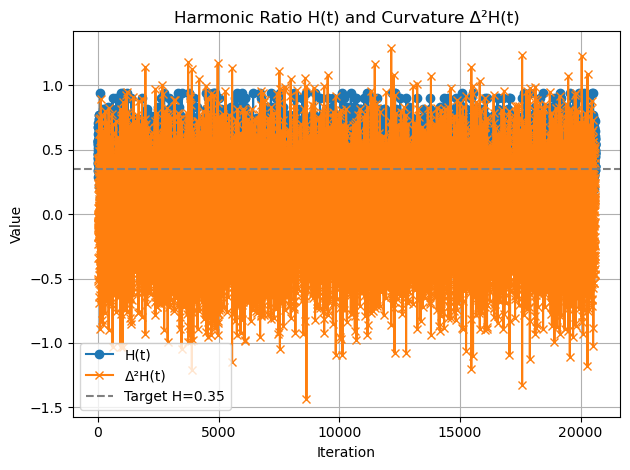


⎇ Cumulative Resonance Deviation: 0.16467
★ Harmonic Convergence Score: 13.7%
↻ Echo Signatures: {'09756659': 50, '19091456': 35, '31652712': 45, '30921861': 34, '69083026': 38, '88109756': 38, '08253344': 43, '90830264': 37, '37867831': 25, '62862089': 32, '75238467': 30, '64252230': 40, '89793238': 45, '12848111': 40, '33786783': 32, '14159265': 40, '97494459': 38, '33208381': 32, '53589793': 43, '23378678': 33, '67351885': 35, '84102701': 27, '48815209': 42, '06171776': 49, '61284756': 39, '32384626': 31, '25334468': 41, '62931767': 33, '05559644': 40, '93751058': 50, '66940513': 56, '64338327': 42, '44090122': 49, '46395224': 35, '15588174': 31, '02884197': 34, '17675238': 48, '89986280': 41, '50582231': 38, '44592307': 36, '21480865': 38, '90122495': 35, '58817488': 40, '66470938': 29, '39522473': 49, '59408128': 52, '82133936': 34, '11055596': 39, '05681271': 41, '06566430': 35, '59036001': 48, '57595919': 36, '09145648': 38, '03600113': 46, '60827785': 48, '65132823': 37, '6566

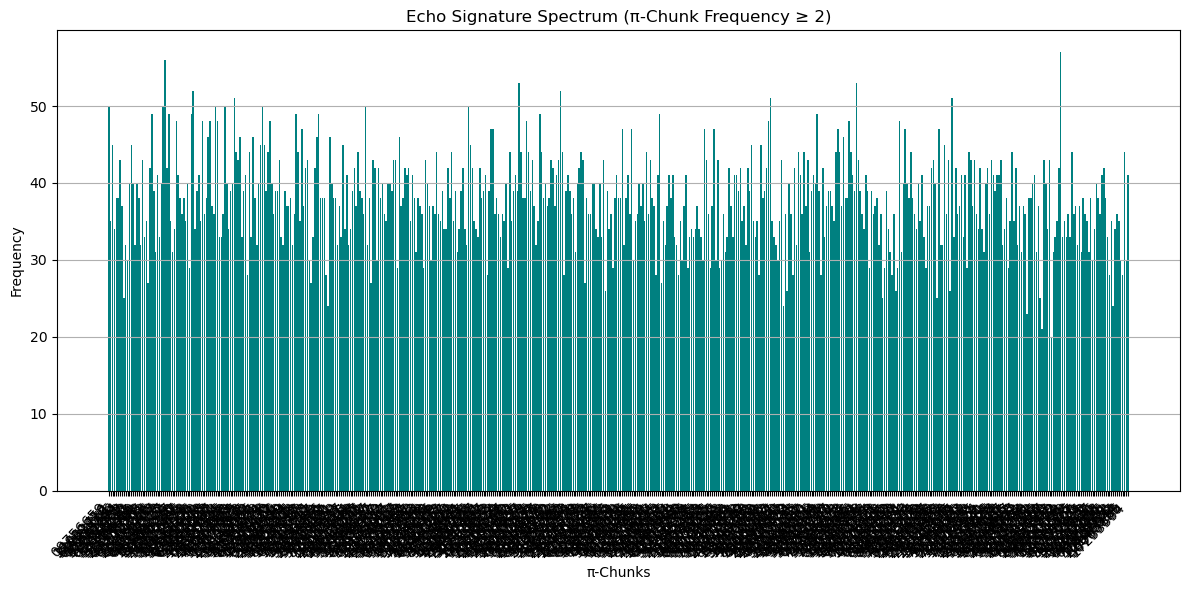

In [10]:
import math
import hashlib
from mpmath import mp
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# Set precision for π digits
mp.dps = 1000000
pi_str = str(mp.pi())[2:1000002]
pi_digits = [int(d) for d in pi_str if d.isdigit()][:10000]

# Constants
HARMONIC_TARGET = 0.35
TWIN_WINDOW = 10

# Twin primes
def get_twin_primes(max_n=1000):
    def is_prime(n):
        if n < 2: return False
        for i in range(2, int(n**0.5)+1):
            if n % i == 0: return False
        return True
    return [(p, p+2) for p in range(2, max_n) if is_prime(p) and is_prime(p+2)]

twin_primes = get_twin_primes(1000)

# Triangle computation
def compute_triangle(a, b):
    c = math.sqrt(a**2 + b**2)
    alpha = math.atan(b / a)
    beta = math.atan(a / b)
    area = 0.5 * a * b
    perimeter = a + b + c
    height = b * a / c
    return {
        'a': a, 'b': b, 'c': c, 'alpha': alpha, 'beta': beta,
        'area': area, 'perimeter': perimeter, 'height': height
    }

# SHA to π index mapping
def map_to_pi_index(tri):
    input_str = f"{tri['a']}:{tri['b']}".encode()
    hash_val = hashlib.sha256(input_str).hexdigest()
    index = int(hash_val, 16) % 10000
    return index, pi_digits[index:index+8]

# Harmonic ratio H(t) calculation
def compute_H(pi_chunk):
    P = sum(pi_chunk[:4])
    A = sum(pi_chunk)
    return P / A if A != 0 else 0

# Curvature Δ²H(t)
def curvature_delta(H_list):
    deltas = [H_list[i] - H_list[i-1] for i in range(1, len(H_list))]
    d2 = [deltas[i] - deltas[i-1] for i in range(1, len(deltas))]
    return d2

# KHRC correction pass
def khrc(H_val, k=1.0, N=0.01):
    return H_val / (1 + k * abs(N))

# Convergence score
def convergence_score(H_vals, target=0.35, margin=0.05):
    return sum(1 for h in H_vals if abs(h - target) <= margin) / len(H_vals)

# Main process
resonant_triangles = []
H_trajectory = []

for a in range(1, 4096):
    for b in range(1, 4096):
        tri = compute_triangle(a, b)
        if 0.34 <= tri['alpha'] <= 0.36 or 0.34 <= tri['beta'] <= 0.36:
            pi_index, pi_chunk = map_to_pi_index(tri)
            for p, q in twin_primes:
                if abs(pi_index - p) < TWIN_WINDOW or abs(pi_index - q) < TWIN_WINDOW:
                    H_val = compute_H(pi_chunk)
                    H_trajectory.append(H_val)
                    resonant_triangles.append({
                        'triangle': tri,
                        'pi_index': pi_index,
                        'pi_chunk': pi_chunk,
                        'twin_prime': (p, q),
                        'H': H_val,
                        'KHRC': khrc(H_val)
                    })
                    break

# Display summary
for res in resonant_triangles[:10]:
    tri = res['triangle']
    print(f"a={tri['a']}, b={tri['b']}, alpha={tri['alpha']:.6f}, beta={tri['beta']:.6f}, "
          f"height={tri['height']:.6f}, H={res['H']:.5f}, KHRC={res['KHRC']:.5f}, "
          f"pi_index={res['pi_index']}, twin_prime={res['twin_prime']}, pi_chunk={res['pi_chunk']}")

# Plot H(t) and Δ²H(t)
if H_trajectory:
    plt.figure()
    plt.plot(H_trajectory, label='H(t)', marker='o')
    d2H = curvature_delta(H_trajectory)
    plt.plot(range(2, 2 + len(d2H)), d2H, label='Δ²H(t)', marker='x')
    plt.axhline(y=HARMONIC_TARGET, color='gray', linestyle='--', label='Target H=0.35')
    plt.title("Harmonic Ratio H(t) and Curvature Δ²H(t)")
    plt.xlabel("Iteration")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Resonance metrics
resonance_deviation = sum(abs(h - HARMONIC_TARGET) for h in H_trajectory) / len(H_trajectory)
score = convergence_score(H_trajectory)
print(f"\n⎇ Cumulative Resonance Deviation: {resonance_deviation:.5f}")
print(f"★ Harmonic Convergence Score: {score*100:.1f}%")

# Echo pattern detection
chunk_strings = [''.join(map(str, chunk)) for chunk in [r['pi_chunk'] for r in resonant_triangles]]
repeats = Counter(chunk_strings)
echo_patterns = {k: v for k, v in repeats.items() if v > 1}
print(f"↻ Echo Signatures: {echo_patterns}")

# Export dataset
df = pd.DataFrame([{
    'a': r['triangle']['a'],
    'b': r['triangle']['b'],
    'alpha': r['triangle']['alpha'],
    'beta': r['triangle']['beta'],
    'height': r['triangle']['height'],
    'H': r['H'],
    'KHRC': r['KHRC'],
    'pi_index': r['pi_index'],
    'pi_chunk': ''.join(map(str, r['pi_chunk'])),
    'twin_prime': f"{r['twin_prime'][0]},{r['twin_prime'][1]}"
} for r in resonant_triangles])

csv_path = "d://Nexus/resonant_triangles_nexus.csv"
df.to_csv(csv_path, index=False)

# Echo spectrum chart
chunk_counter = Counter(''.join(map(str, r['pi_chunk'])) for r in resonant_triangles)
echo_chunks = {k: v for k, v in chunk_counter.items() if v > 1}

if echo_chunks:
    plt.figure(figsize=(12, 6))
    plt.bar(echo_chunks.keys(), echo_chunks.values(), color='teal')
    plt.title("Echo Signature Spectrum (π-Chunk Frequency ≥ 2)")
    plt.xlabel("π-Chunks")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()
else:
    print("No π-chunks repeated more than once.")
